<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/labs/l2chi2unittest_and_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pylab as pl
import scipy as sp
from scipy import optimize

In [ ]:
# this is the cell of code to give to students
def line(a, b, x):
  return a*x + b

In [ ]:

def L2(theta, x, y, func=line):
    
    return np.sum((line(*theta, x) - y)**2)

def chi2(theta, x, y, yerr, func=line):
    
    return np.sum((line(*theta, x) - y)**2 / yerr**2)

L2 unit test: result should be -8.33237568 111.93751462: [ -8.33237568 111.93751462]
chi22 unit test: result should be -7.21374685 104.93611121: [ -7.21374685 104.93611121]


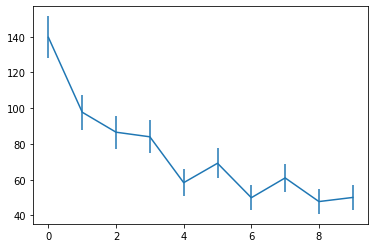

In [ ]:

np.random.seed(222)
y = np.array([120, 95, 82, 74, 66, 62, 59, 51, 53, 47]) 
y = y + np.random.randn(len(y)) * 10
yerr = np.sqrt(y)
x = np.arange(len(y))

pl.errorbar(x, y, yerr=yerr);

print("L2 unit test: result should be -8.33237568 111.93751462:", sp.optimize.minimize(L2, (10,40), args=(x, y, line)).x)
print("chi22 unit test: result should be -7.21374685 104.93611121:", sp.optimize.minimize(chi2, (10,40), args=(x, y, yerr, line)).x)



# overfitting demo : which model is "better"
clue, it depends on how you define better!


In [ ]:
np.polyfit?

In [ ]:
def fitpoly(polydeg, x, y, yerr, plot=True):
  """Function to demonstrate the risks of overfitting in increasing model complexity
  Calculates a polynomial of "polydeg" degree fit to the input data
  Plots the data, colored by in-sample (training, orange) and out-of-sample (validation, blue)
  prints the model L2 for the in-sample data and out of sample data

  Input: 
  polydeg: the degree of the polynomial - higher degree more model complexity
  x (array): the exogenous variable
  y (array): the endogenous variable
  yerr (array): the uncertainty in the endogenous variable (plotted but not used)
  Output: returns the in and (out of sample L2 (a tuple)
  """
  model = np.poly1d(np.polyfit(x[1:-1], y[1:-1], polydeg))
  if plot:
    pl.errorbar(x, y, yerr=yerr);
    pl.errorbar(x[1:-1], y[1:-1], yerr=yerr[1:-1], fmt='.', 
              label="points used for fit");
    pl.xlabel("x")
    pl.ylabel("y")
    pl.plot(x, model(x), 
          label="polynomial model deg %d"%polydeg)
    pl.legend()
  print("L2 insample %.2g"%np.sum((y[1:-1] - model(x[1:-1]))**2))
  print("L2 outofsample %.2f"%(np.sum((y[0::len(x)-2] - model(x[0::len(x)-2]))**2)))
  return (np.sum((y[1:-1] - model(x[1:-1]))**2), np.sum((y[0::len(x)-2] - model(x[0::len(x)-2]))**2))

L2 insample 4.2e+02
L2 outofsample 1590.19


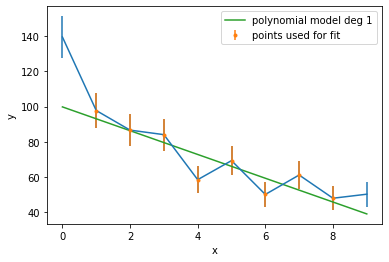

In [ ]:
fitpoly(1, x, y, yerr);

L2 insample 3.3e+02
L2 outofsample 822.42


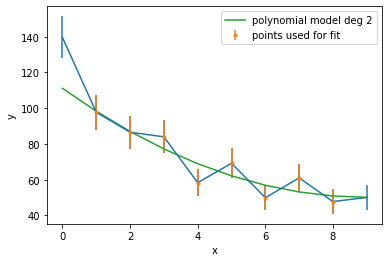

In [ ]:
fitpoly(2, x, y, yerr);

L2 insample 3.3e+02
L2 outofsample 709.80


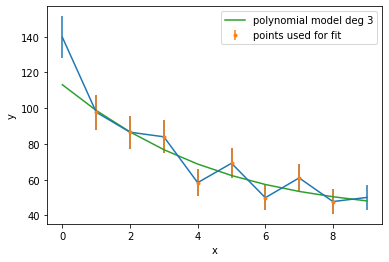

In [ ]:
fitpoly(3, x, y, yerr);

L2 insample 2.7e+02
L2 outofsample 263.94


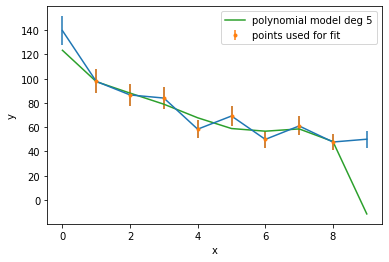

In [ ]:
fitpoly(5, x, y, yerr);

L2 insample 2.7e+02
L2 outofsample 3189.61


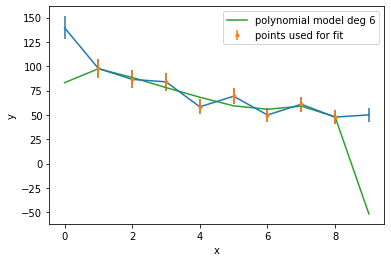

In [ ]:
fitpoly(6, x, y, yerr);

L2 insample 2.9e-21
L2 outofsample 335389.25


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: RankWarning: Polyfit may be poorly conditioned
  """Entry point for launching an IPython kernel.


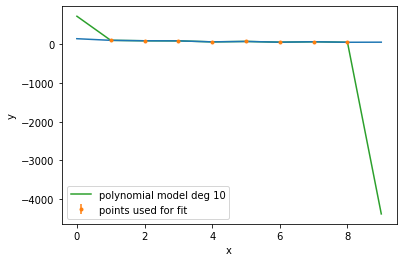

In [ ]:
fitpoly(len(x), x, y, yerr);

L2 insample 4.2e+02
L2 outofsample 1590.19
L2 insample 3.3e+02
L2 outofsample 822.42
L2 insample 3.3e+02
L2 outofsample 709.80
L2 insample 2.9e+02
L2 outofsample 2622.49
L2 insample 2.7e+02
L2 outofsample 263.94
L2 insample 2.7e+02
L2 outofsample 3189.61
L2 insample 6.3e-19
L2 outofsample 3082005.73
L2 insample 7.1e-19
L2 outofsample 1295587.34
L2 insample 1.4e-20
L2 outofsample 623565.10


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: RankWarning: Polyfit may be poorly conditioned
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: RankWarning: Polyfit may be poorly conditioned
  """Entry point for launching an IPython kernel.


Text(0, 0.5, 'out of sample fit results')

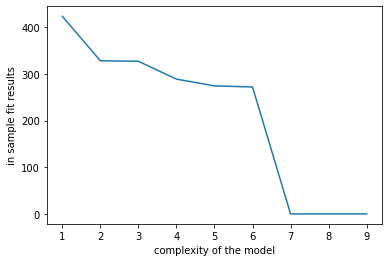

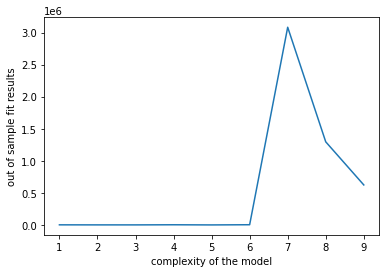

In [ ]:
outofsampleresult = np.array([fitpoly(i, x, y, yerr, plot=False) for i in range(1,len(x))])

pl.figure()
pl.plot(range(1,len(x)), outofsampleresult[:,0])  
pl.xlabel("complexity of the model")
pl.ylabel("in sample fit results")

pl.figure()
pl.plot(range(1,len(x)), outofsampleresult[:,1])  
pl.xlabel("complexity of the model")
pl.ylabel("out of sample fit results")


In [ ]:
model1 = np.poly1d(np.polyfit(x[1:-1], y[1:-1], 1))
model2 = np.poly1d(np.polyfit(x[1:-1], y[1:-1], 2))


set alpha = 0.05

calculate likelihood



In [ ]:
def loglikelihood(x, y, model):
  return  - np.sum(np.log(1 / np.sqrt(2*np.pi) / yerr)) + np.sum(0.5 * ((model(x) - y)**2) / yerr**2)


In [ ]:
model1, loglikelihood(x, y, model1)

(poly1d([-6.77308916, 99.81570905]), 40.976336800315735)

In [ ]:
model2, loglikelihood(x, y, model2)

(poly1d([  0.75404018, -13.5594508 , 111.12631179]), 36.04915446055468)

In [ ]:
import scipy.stats as sps


In [ ]:
-2 * (loglikelihood(x, y, model1) - loglikelihood(x, y, model2))

9.854364679522106

In [ ]:
from scipy.stats import chi2 
chi2.sf(-2 * (loglikelihood(x, y, model1) - loglikelihood(x, y, model2)), 1)

0.0016942929998074912

In [ ]:
import statsmodels.api as sm
import pandas as pd

In [ ]:
exog = sm.add_constant(x)
endog = y
weights = 1.0 / (yerr ** 2)
wls = sm.WLS(endog, exog, weights).fit(cov_type="fixed scale")
wls.summary()

/usr/local/lib/python3.7/dist-packages/scipy/stats/stats.py:1535: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.743
Model:                            WLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     56.84
Date:                Mon, 11 Oct 2021   Prob (F-statistic):           6.68e-05
Time:                        12:50:58   Log-Likelihood:                -38.834
No. Observations:                  10   AIC:                             81.67
Df Residuals:                       8   BIC:                             82.27
Df Model:                           1                                         
Covariance Type:          fixed scale                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.9361      5.681     18.470      0.000      93.801     116.071
x1            -7.2137      0.957     -7.539      0.000      -9.089      -5.338
==============================================================================
Omnibus:                        0.755   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.076
Skew:                           0.210   Prob(JB):                        0.963
Kurtosis:                       2.922   Cond. No.                         13.3
==============================================================================

Warnings:
[1] Standard Errors are based on fixed scale
"""

In [ ]:
def calculate_aic(x, y, model):
	aic = len(x) * loglikelihood(x, y, model) + 2 * len(model)
	return aic

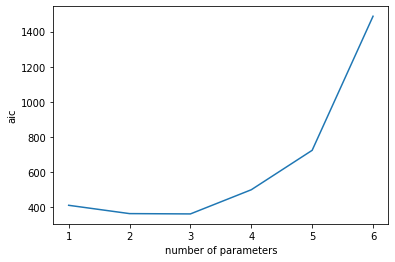

In [ ]:
pl.plot(range(1,7),
        [calculate_aic(x, y, np.poly1d(np.polyfit(x[1:-1], y[1:-1], i))) for i in range(1,7)])
pl.xlabel("number of parameters")
pl.ylabel("aic");

In [ ]:
def calculate_bic(x, y, model):
	bic = 2 * loglikelihood(x, y, model) + np.log(len(x)) * len(model)
	return bic

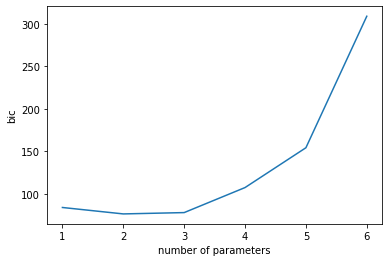

In [ ]:
pl.plot(range(1,7),
        [calculate_bic(x, y, np.poly1d(np.polyfit(x[1:-1], y[1:-1], i))) for i in range(1,7)])
pl.xlabel("number of parameters")
pl.ylabel("bic");